In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs, load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_curve, roc_auc_score, precision_recall_curve, auc,
                             confusion_matrix, classification_report, mean_squared_error, 
                             mean_absolute_error, r2_score)

from numpy import argmax
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.model_selection import cross_validate

In [2]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

In [3]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


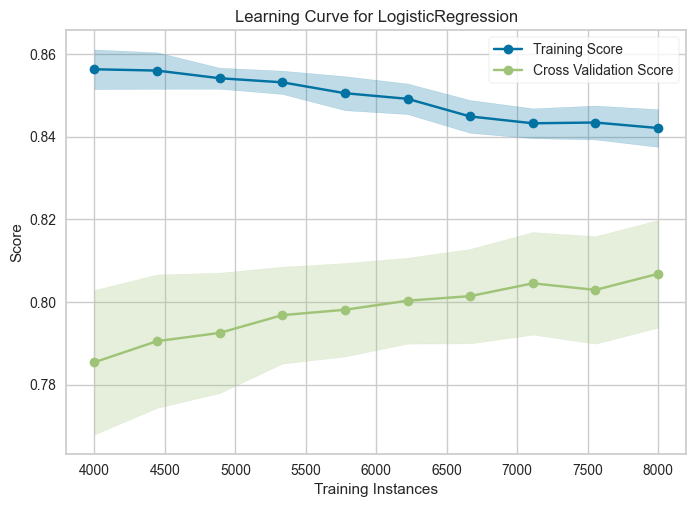

In [4]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show() 

In [5]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


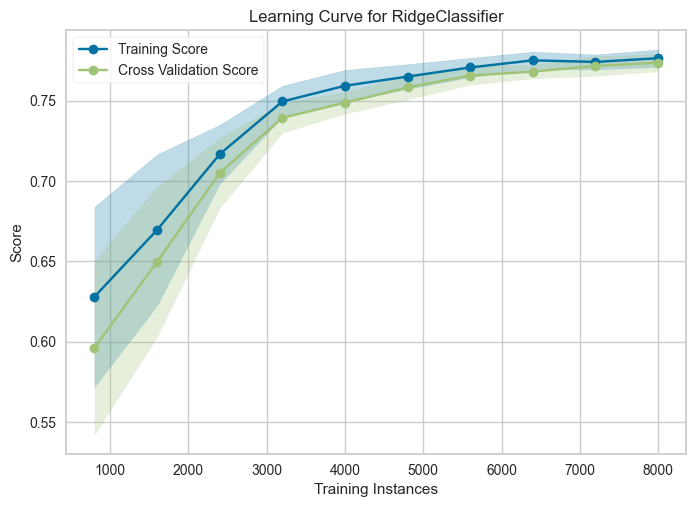

In [6]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

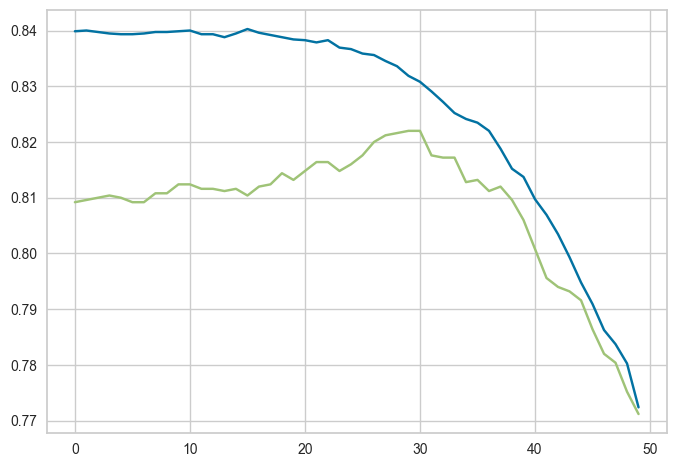

In [7]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

In [9]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


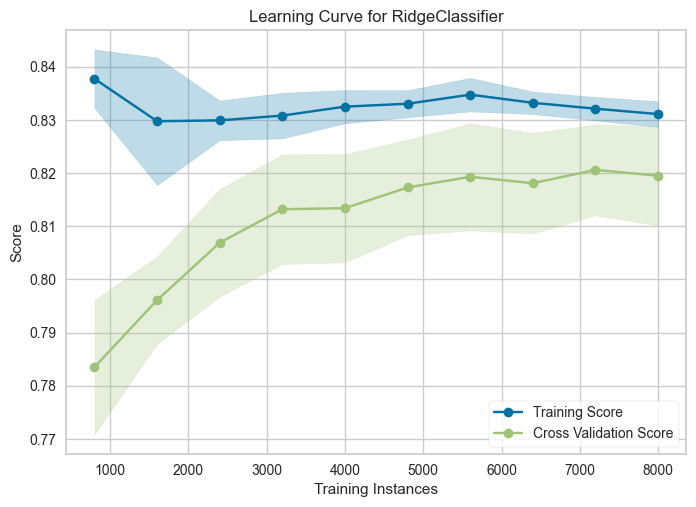

In [10]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

In [14]:
from numpy import genfromtxt
dataset = fetch_california_housing()
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

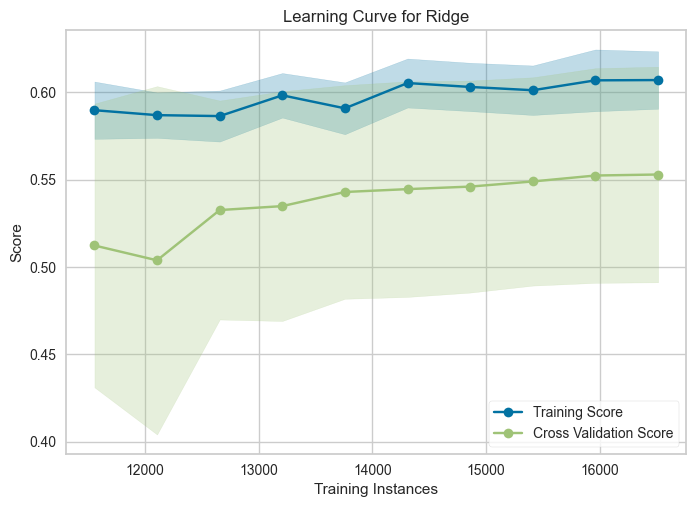

In [16]:
from sklearn.linear_model import Ridge
from yellowbrick.model_selection import LearningCurve
visualizer = LearningCurve(
    Ridge(alpha=0.0001), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y) .show() 

In [18]:
from sklearn.linear_model import Ridge

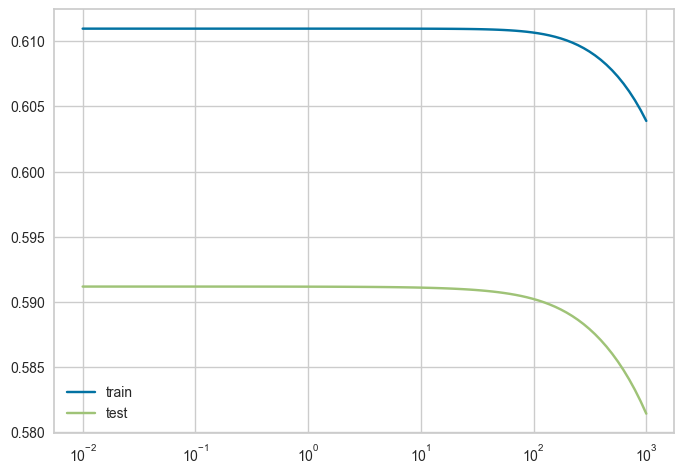

In [21]:
trains = []
tests = []
alphas = np.logspace(-2, 3, 100)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(alphas, trains, label="train")
plt.plot(alphas, tests, label="test")
plt.xscale('log')
plt.legend()
plt.show()

In [22]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.61
Linear Regression-Test set score: 0.59


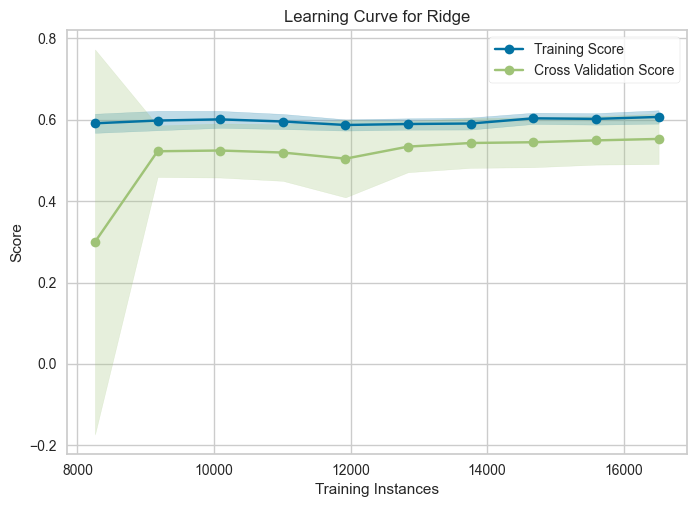

In [23]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show() 

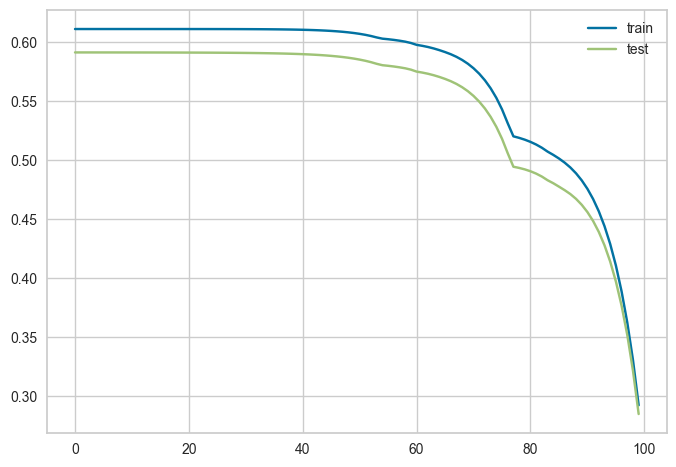

In [24]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
  ridge = Lasso(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [25]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv',nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


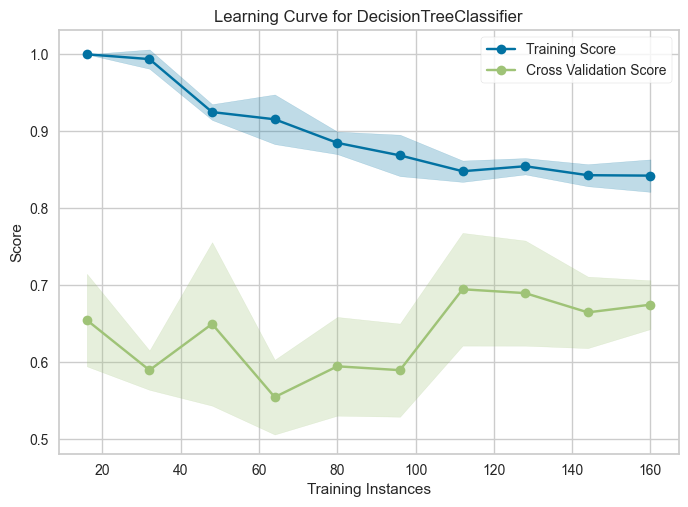

In [28]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show() 

In [32]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

1.0
0.55


In [33]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='delta_ailerons', parser="auto")
data.data.shape

(7129, 5)

In [34]:
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


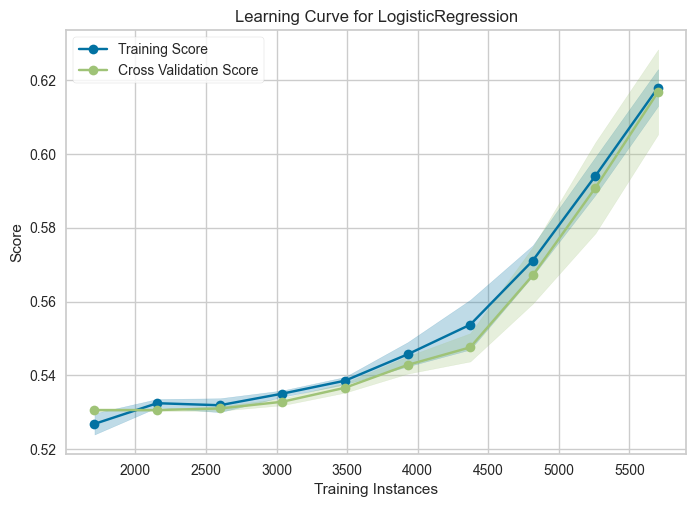

In [36]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show() 

In [37]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9372
Test score = 0.9362


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


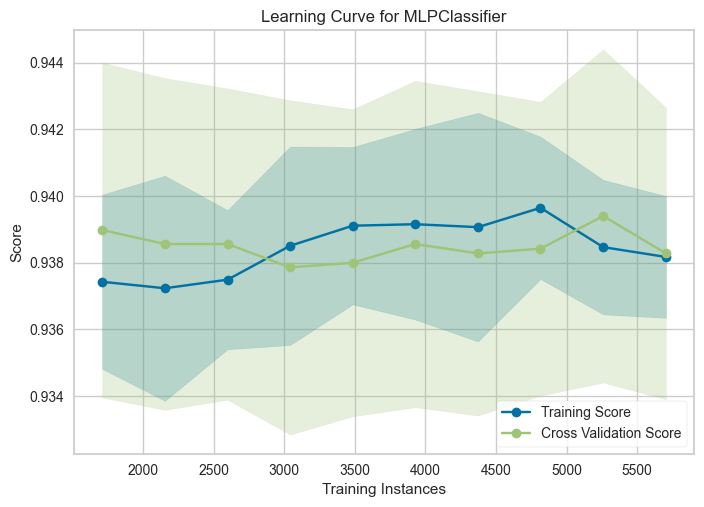

<Axes: title={'center': 'Learning Curve for MLPClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [41]:
visualizer = LearningCurve(
    MLPClassifier(max_iter=1000, random_state=42), 
    scoring='accuracy', 
    train_sizes=np.linspace(0.3, 1.0, 10)
)
visualizer.fit(X, y)
visualizer.show()

In [42]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


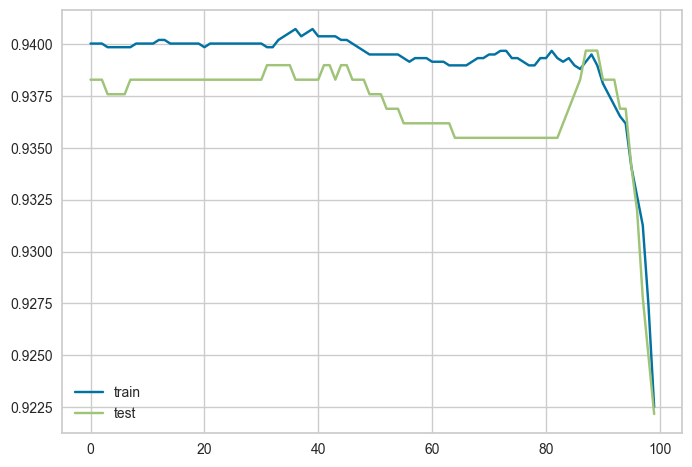

In [43]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
  ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
  trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
  tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

## Практическая работа

### 1. Диагностика модели классификации с другими метриками эффективности

In [45]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv', nrows=400)

In [46]:
y = df["Outcome"]
X = df.drop("Outcome", axis=1)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [53]:
cv_results = cross_validate(model, X_train, y_train, cv=5, scoring='f1')
print(f"Кросс-валидация F1-score: {cv_results['test_score']}")
print(f"Среднее: {cv_results['test_score'].mean():.4f}")

Кросс-валидация F1-score: [0.52       0.55319149 0.59259259 0.48979592 0.54545455]
Среднее: 0.5402


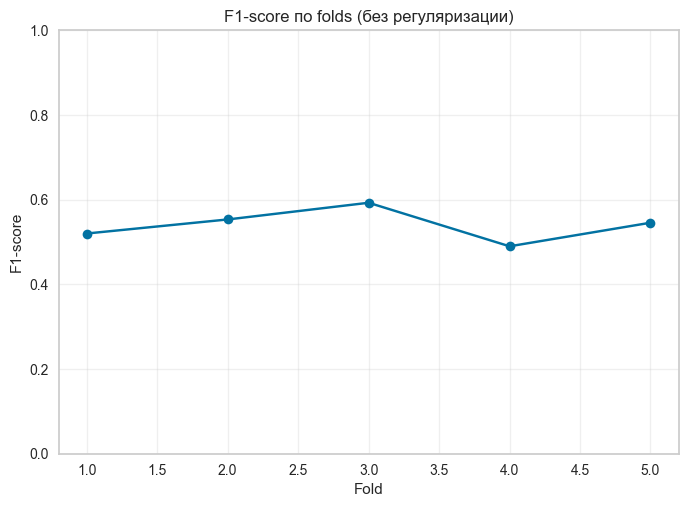

In [55]:
plt.plot(range(1, 6), cv_results['test_score'], marker='o')
plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.title('F1-score по folds (без регуляризации)')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
model_reg = DecisionTreeClassifier(random_state=1, max_depth=3)
model_reg.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
y_train_pred_reg = model_reg.predict(X_train)
y_test_pred_reg = model_reg.predict(X_test)

In [58]:
cv_results_reg = cross_validate(model_reg, X_train, y_train, cv=5, scoring='f1')

In [60]:
print(f"Кросс-валидация F1-score (регуляризованная): {cv_results_reg['test_score']}")
print(f"Среднее: {cv_results_reg['test_score'].mean():.4f}")

Кросс-валидация F1-score (регуляризованная): [0.33333333 0.5        0.54054054 0.5        0.47058824]
Среднее: 0.4689


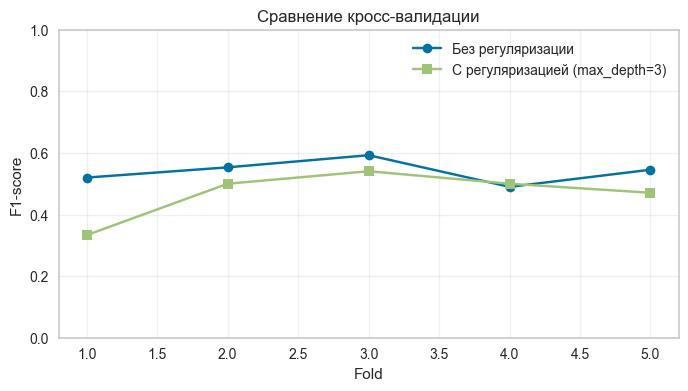

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_results['test_score'], marker='o', label='Без регуляризации')
plt.plot(range(1, 6), cv_results_reg['test_score'], marker='s', label='С регуляризацией (max_depth=3)')
plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.title('Сравнение кросс-валидации')
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
df_full = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
y_full = df_full["Outcome"]
X_full = df_full.drop("Outcome", axis=1)

In [63]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

In [64]:
model_full = DecisionTreeClassifier(random_state=1, max_depth=3)
model_full.fit(X_train_full, y_train_full)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_train_pred_full = model_full.predict(X_train_full)
y_test_pred_full = model_full.predict(X_test_full)

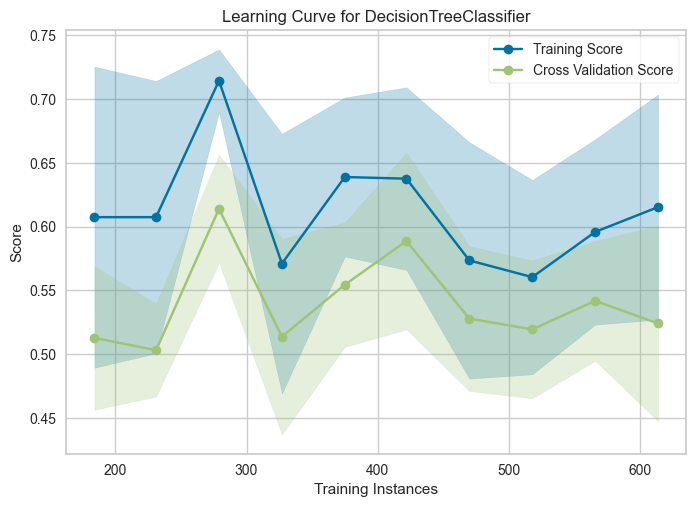

<Axes: title={'center': 'Learning Curve for DecisionTreeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [67]:
visualizer = LearningCurve(
    DecisionTreeClassifier(random_state=1, max_depth=3),
    scoring='f1',
    train_sizes=np.linspace(0.3, 1.0, 10)
)
visualizer.fit(X_full, y_full)
visualizer.show()

### 2. Диагностика модели регрессии

In [86]:
data = fetch_california_housing()
X = data.data
y = data.target

In [87]:
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.25, random_state=0)

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
k_vals = range(1, 51)
train_knn, test_knn = [], []
for k in k_vals:
    model = KNeighborsRegressor(n_neighbors=k).fit(X_train_scaled, y_train)
    train_knn.append(r2_score(y_train, model.predict(X_train_scaled)))
    test_knn.append(r2_score(y_test, model.predict(X_test_scaled)))

In [90]:
C_vals = np.logspace(-2, 2, 10)
train_svr, test_svr = [], []
for C in C_vals:
    model = SVR(kernel='rbf', C=C).fit(X_train_scaled, y_train)
    train_svr.append(r2_score(y_train, model.predict(X_train_scaled)))
    test_svr.append(r2_score(y_test, model.predict(X_test_scaled)))

In [92]:
depth_vals = range(1, 21)
train_tree, test_tree = [], []
for d in depth_vals:
    model = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    train_tree.append(r2_score(y_train, model.predict(X_train)))
    test_tree.append(r2_score(y_test, model.predict(X_test)))

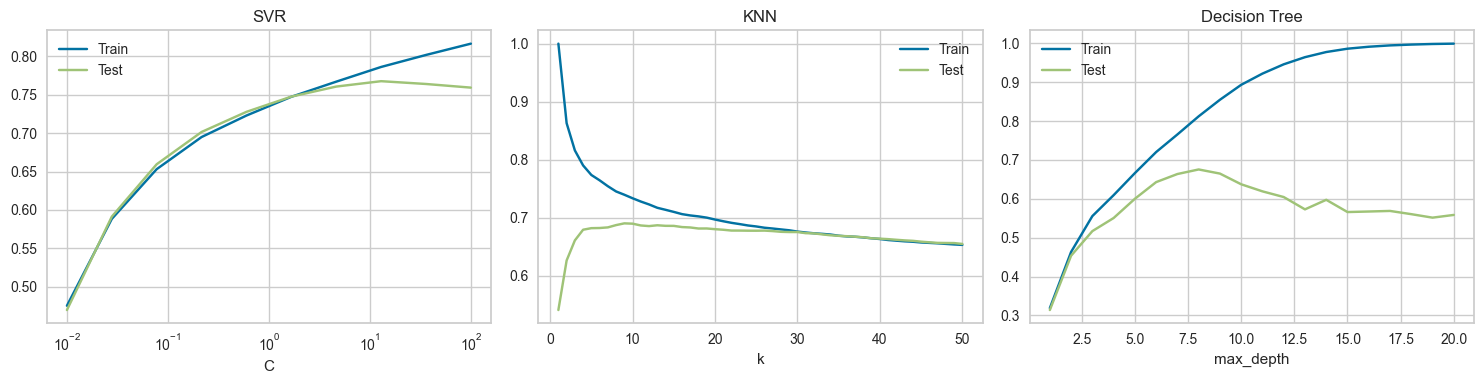

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(C_vals, train_svr, label='Train')
axes[0].semilogx(C_vals, test_svr, label='Test')
axes[0].set_xlabel('C')
axes[0].set_title('SVR')
axes[0].legend()

axes[1].plot(k_vals, train_knn, label='Train')
axes[1].plot(k_vals, test_knn, label='Test')
axes[1].set_xlabel('k')
axes[1].set_title('KNN')
axes[1].legend()

axes[2].plot(depth_vals, train_tree, label='Train')
axes[2].plot(depth_vals, test_tree, label='Test')
axes[2].set_xlabel('max_depth')
axes[2].set_title('Decision Tree')
axes[2].legend()

plt.tight_layout()
plt.show()

### 3. Датасет Бостон

In [94]:
data = fetch_california_housing()
X = data.data
y = data.target

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
alpha_vals = np.logspace(-4, 1, 50)
train_scores = []
test_scores = []

In [98]:
for alpha in alpha_vals:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    train_scores.append(r2_score(y_train, lasso.predict(X_train_scaled)))
    test_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))

In [99]:
best_idx = np.argmax(test_scores)
best_alpha = alpha_vals[best_idx]

In [100]:
print(f"Оптимальный alpha: {best_alpha:.4f}")
print(f"Train R2: {train_scores[best_idx]:.4f}")
print(f"Test R2: {test_scores[best_idx]:.4f}")

Оптимальный alpha: 0.0001
Train R2: 0.6110
Test R2: 0.5912


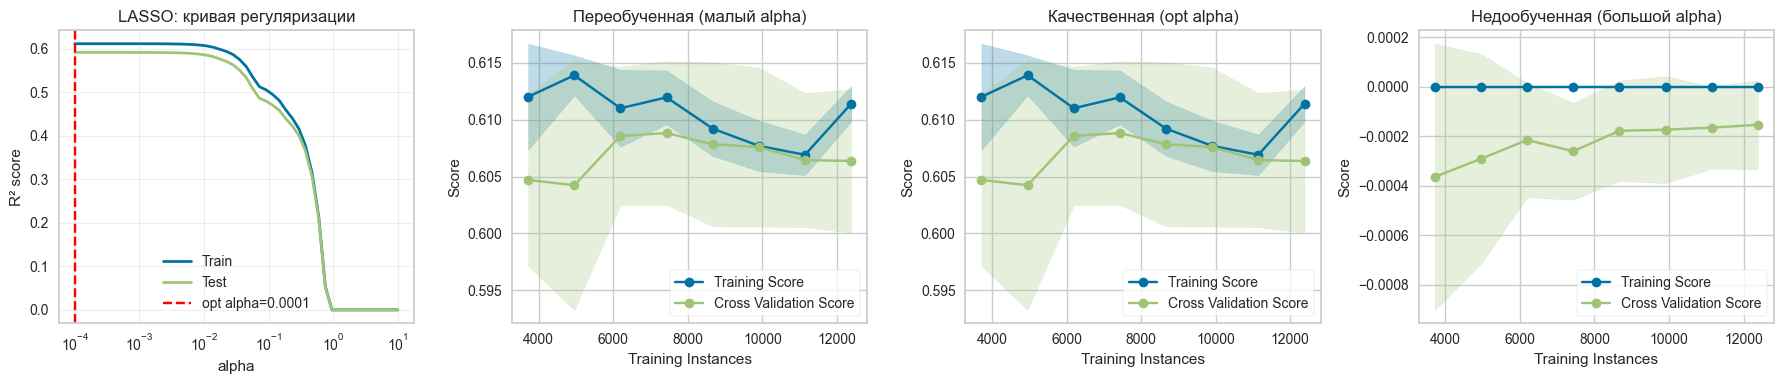

In [112]:
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.semilogx(alpha_vals, train_scores, label='Train', linewidth=2)
plt.semilogx(alpha_vals, test_scores, label='Test', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'opt alpha={best_alpha:.4f}')
plt.xlabel('alpha')
plt.ylabel('R² score')
plt.title('LASSO: кривая регуляризации')
plt.legend()
plt.grid(True, alpha=0.3)

alphas_to_plot = [alpha_vals[0], best_alpha, alpha_vals[-1]]
titles = ['Переобученная (малый alpha)', 'Качественная (opt alpha)', 'Недообученная (большой alpha)']

for i, (alpha, title) in enumerate(zip(alphas_to_plot, titles)):
    plt.subplot(1, 4, i+2)
    
    from yellowbrick.model_selection import LearningCurve
    visualizer = LearningCurve(
        Lasso(alpha=alpha, max_iter=10000, random_state=42),
        scoring='r2',
        train_sizes=np.linspace(0.3, 1.0, 8),
        cv=5
    )
    visualizer.fit(X_train_scaled, y_train)
    visualizer.finalize()
    plt.title(title)

plt.tight_layout()
plt.show()

In [107]:
lasso_opt = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_opt.fit(X_train_scaled, y_train)

,alpha,np.float64(0.0001)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [108]:
coef_df = pd.DataFrame({
    'feature': data.feature_names,
    'coef': lasso_opt.coef_
})
print(coef_df)
print(f"\nКоличество нулевых коэффициентов: {np.sum(np.abs(lasso_opt.coef_) < 1e-5)} из {len(lasso_opt.coef_)}")

      feature      coef
0      MedInc  0.831381
1    HouseAge  0.121035
2    AveRooms -0.260340
3   AveBedrms  0.302642
4  Population -0.008593
5    AveOccup -0.029775
6    Latitude -0.891282
7   Longitude -0.862709

Количество нулевых коэффициентов: 0 из 8


### 4. ElasticNet

In [117]:
from sklearn.linear_model import ElasticNet

In [113]:
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [115]:
alpha_vals = np.logspace(-3, 1, 20)
l1_ratios = [0.1, 0.5, 0.7, 0.9, 1.0]

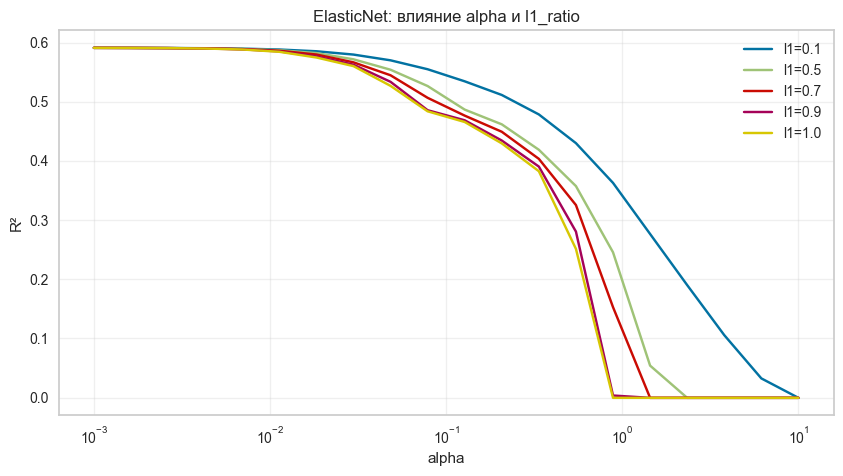

In [119]:
plt.figure(figsize=(10, 5))
for l1 in l1_ratios:
    scores = []
    for alpha in alpha_vals:
        model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, random_state=42)
        model.fit(X_train_scaled, y_train)
        scores.append(r2_score(y_test, model.predict(X_test_scaled)))
    plt.semilogx(alpha_vals, scores, label=f'l1={l1}')

plt.xlabel('alpha')
plt.ylabel('R²')
plt.title('ElasticNet: влияние alpha и l1_ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Доп анализ дерева решений из третьего примера 

In [120]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
y = df["Outcome"]
X = df.drop("Outcome", axis=1)

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
depths = range(1, 21)
train_f1 = []
test_f1 = []

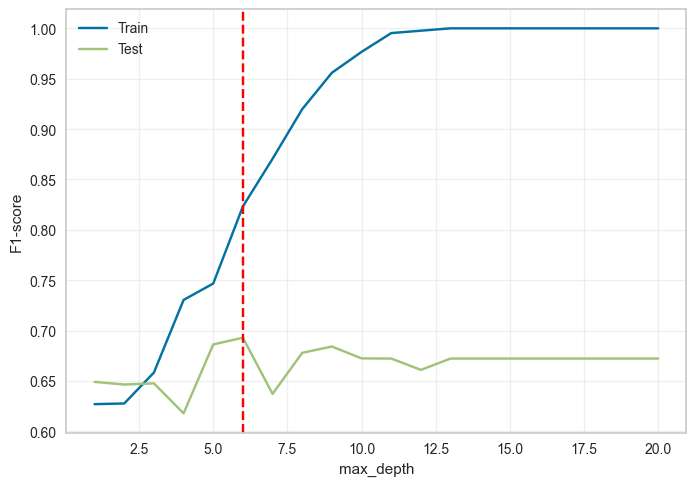

In [123]:
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, tree.predict(X_train)))
    test_f1.append(f1_score(y_test, tree.predict(X_test)))

best_depth = depths[np.argmax(test_f1)]

plt.plot(depths, train_f1, label='Train')
plt.plot(depths, test_f1, label='Test')
plt.axvline(best_depth, color='red', linestyle='--')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [124]:
print(f"Оптимальная глубина: {best_depth}")
print(f"Test F1: {max(test_f1):.4f}")

Оптимальная глубина: 6
Test F1: 0.6929


### 6. Анализ для других датасетов

In [125]:
datasets = [
    'phoneme', 'banknote-authentication', 'delta_ailerons',
    'mammography', 'electricity', 'mozilla4', 'kropt', 'nursery'
]

In [130]:
for name in datasets:
    print(f"Датасет: {name}")
    data = fetch_openml(name=name, parser='auto', as_frame=True)
    X, y = data.data, data.target

    if y.dtype == 'object' or y.dtype.name == 'category':
        y = LabelEncoder().fit_transform(y)

    X = X.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype == 'object' or col.dtype.name == 'category' else col)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    if name == 'delta_ailerons':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        print(f"R2: {r2_score(y_test, model.predict(X_test)):.4f}")

    else:
        tree = DecisionTreeClassifier(random_state=42)
        tree.fit(X_train, y_train)
        print(f"Дерево - Test F1: {f1_score(y_test, tree.predict(X_test), average='macro'):.4f}")
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        print(f"Random Forest - Test F1: {f1_score(y_test, rf.predict(X_test), average='macro'):.4f}")
    print('-' * 40)

Датасет: phoneme
Дерево - Test F1: 0.8152


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)


Random Forest - Test F1: 0.8917
----------------------------------------
Датасет: banknote-authentication
Дерево - Test F1: 0.9817
Random Forest - Test F1: 0.9927
----------------------------------------
Датасет: delta_ailerons
R2: 0.8208
----------------------------------------
Датасет: mammography
Дерево - Test F1: 0.8333
Random Forest - Test F1: 0.8633
----------------------------------------
Датасет: electricity
Дерево - Test F1: 0.8814


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name electricity exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=151
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43945

  warn(warning_msg)


Random Forest - Test F1: 0.9035
----------------------------------------
Датасет: mozilla4
Дерево - Test F1: 0.9281
Random Forest - Test F1: 0.9521
----------------------------------------
Датасет: kropt
Дерево - Test F1: 0.8583
Random Forest - Test F1: 0.8261
----------------------------------------
Датасет: nursery
Дерево - Test F1: 0.7900


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)


Random Forest - Test F1: 0.7621
----------------------------------------


**Случайный лес** превосходит дерево решений на 5 из 7 датасетов (в среднем на **+4.6%** по F1). Исключения: `kropt` и `nursery`, где дерево оказалось лучше.

**Лучший датасет:** `banknote-authentication` (F1 = 0.99)  
**Худший:** `nursery` (F1 = 0.76)

**Регрессия** (`delta_ailerons`): R² = 0.82 — умеренное переобучение.